# Activity Recognition using Hidden Markov Models

## 1. Data Preprocessing and Exploratory Data Analysis
The primary objective of this phase is to ingest the raw accelerometer and gyroscope data, verify its structural integrity, and perform initial visual exploratory data analysis.

Understanding the underlying sampling rate is critical for establishing the sequence window size. Assuming the data collection devices operated at a sampling frequency of 50 Hz, a one second recording yields 50 discrete data points. Human activities like walking or jumping typically exhibit cyclic patterns within a one to two second timeframe. Therefore, a window size of 50 samples (1 second) is selected to capture a complete movement cycle while providing enough sequential observations for the Hidden Markov Model.

The exploratory visualizations confirm the signal variance across different activity states, validating the hypothesis that motion states can be differentiated through sensor data.


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from hmmlearn import hmm

# Configure plotting aesthetics
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style="whitegrid")

def load_sensor_data(filepath: str) -> pd.DataFrame:
    """
    Loads raw sensor data and standardizes the time index to elapsed seconds.
    
    Args:
        filepath (str): Path to the target CSV file.
        
    Returns:
        pd.DataFrame: DataFrame containing normalized time, accelerometer, and gyroscope readings.
    """
    df = pd.read_csv(filepath)
    
    if 'time' in df.columns:
        # Subtract the first timestamp from all rows so the recording starts at 0.0
        df['time'] = df['time'] - df['time'].iloc[0]
        
        # If the elapsed time values are excessively large, they are in nanoseconds.
        # Convert nanoseconds to standard seconds.
        if df['time'].max() > 1e7:
            df['time'] = df['time'] / 1e9
            
        df.set_index('time', inplace=True)
        
    return df

def plot_sensor_signals(df: pd.DataFrame, activity_name: str) -> None:
    """
    Generates a time-series plot of the 3-axis accelerometer data using elapsed seconds.
    
    Args:
        df (pd.DataFrame): Sensor data with time as the index.
        activity_name (str): Label for the plot title.
    """
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # The index is now a standard float representing elapsed seconds
    ax.plot(df.index, df['x_acc'], label='X-Axis', alpha=0.8)
    ax.plot(df.index, df['y_acc'], label='Y-Axis', alpha=0.8)
    ax.plot(df.index, df['z_acc'], label='Z-Axis', alpha=0.8)
    
    ax.set_title(f'Accelerometer Signal Profile: {activity_name}')
    ax.set_xlabel('Time (Seconds)')
    ax.set_ylabel('Acceleration (m/s²)')
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

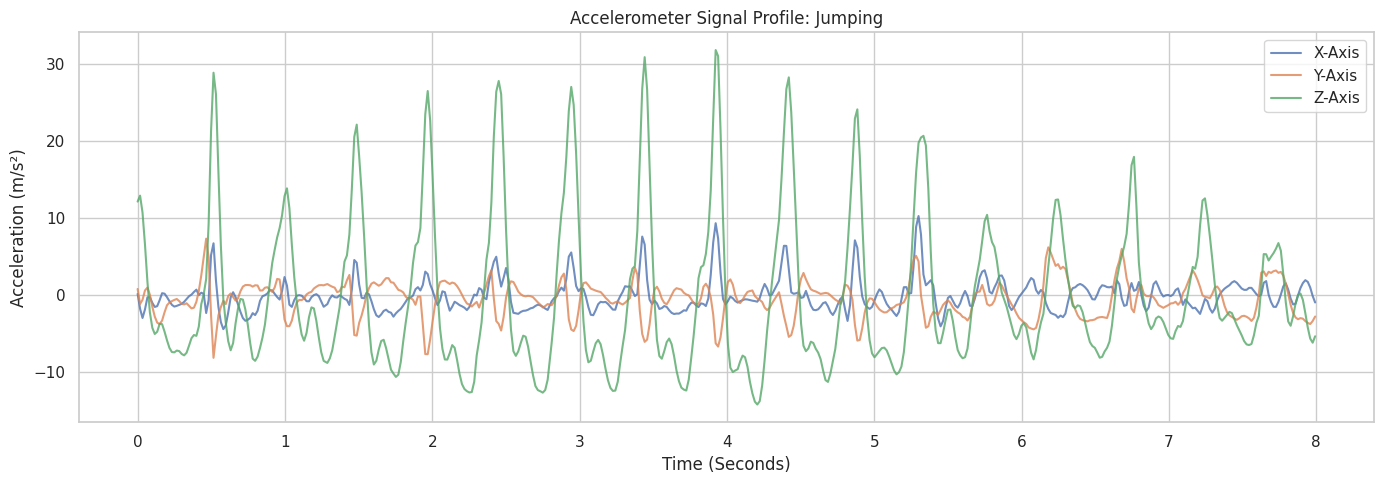

In [3]:
import random

# Dynamically resolve the path by stepping up one directory from the notebook's location
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)
raw_data_dir = os.path.join(project_root, 'data', 'raw')

if os.path.exists(raw_data_dir):
    csv_files = [f for f in os.listdir(raw_data_dir) if f.endswith('.csv')]
    
    if csv_files:
        random_file = random.choice(csv_files)
        filepath = os.path.join(raw_data_dir, random_file)
        
        # Extract the activity name from the filename 
        activity_label = random_file.split('_')[0].capitalize()
        
        # Load and visualize the data
        sample_df = load_sensor_data(filepath)
        plot_sensor_signals(sample_df, activity_label)
    else:
        print(f"Directory '{raw_data_dir}' is empty. Please check the extraction step.")
else:
    print(f"Directory '{raw_data_dir}' does not exist. Check the project structure.")

## 2.1 Feature Engineering and Normalization
To effectively model the hidden states, the raw time-series data must be transformed into a robust observation sequence. Features are extracted from both the time and frequency domains for each sequential data window.Time-Domain FeaturesTime-domain features capture the signal's amplitude and dispersion.Variance: Quantifies the spread of the acceleration values, which is crucial for distinguishing dynamic activities like jumping from static ones like standing.$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$Root Mean Square (RMS): Measures the average magnitude of the signal, providing a reliable indicator of overall movement intensity.$$RMS = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}$$Frequency-Domain FeaturesFrequency-domain features analyze the periodicity of the movements.Dominant Frequency: Extracted via the Fast Fourier Transform (FFT). It identifies the most prominent rhythmic component in the window, making it highly effective for recognizing the steady cadence of walking.NormalizationAll extracted features are normalized using Z-score standardization. This ensures that features with larger numerical ranges do not disproportionately influence the Baum-Welch optimization algorithm during model training.$$z = \frac{x - \mu}{\sigma}$$

In [12]:
from scipy.fft import fft, fftfreq

def extract_features(window: np.ndarray, sampling_rate: int = 50) -> np.ndarray:
    """
    Extracts time and frequency domain features from a single data window,
    incorporating a noise gate for stationary signals.
    """
    features = []
    
    for axis in range(window.shape[1]):
        signal = window[:, axis]
        
        # Time-domain features
        variance = np.var(signal)
        rms = np.sqrt(np.mean(np.square(signal)))
        
        # The Mathematical Fix: The Noise Gate
        # If variance is less than 0.001, the device is functionally completely still.
        # We force the frequency to 0.0 to prevent the FFT from amplifying sensor noise.
        if variance < 1e-3:
            peak_freq = 0.0
        else:
            fft_values = fft(signal)
            fft_freqs = fftfreq(len(signal), 1 / sampling_rate)
            
            pos_mask = fft_freqs > 0
            peak_freq = fft_freqs[pos_mask][np.argmax(np.abs(fft_values[pos_mask]))]
            
        features.extend([variance, rms, peak_freq])
        
    return np.array(features)

def create_feature_sequences(df: pd.DataFrame, window_size: int = 50) -> np.ndarray:
    """
    Segments a dataframe into sequential windows and extracts features for each.
    
    Args:
        df (pd.DataFrame): The raw sensor data.
        window_size (int): Number of samples per window.
        
    Returns:
        np.ndarray: A 2D array where each row represents the feature vector of a window.
    """
    data_matrix = df[['x_acc', 'y_acc', 'z_acc', 'x_gyro', 'y_gyro', 'z_gyro']].values
    num_windows = len(data_matrix) // window_size
    
    sequence_features = []
    for i in range(num_windows):
        start_idx = i * window_size
        end_idx = start_idx + window_size
        window_data = data_matrix[start_idx:end_idx, :]
        
        window_features = extract_features(window_data)
        sequence_features.append(window_features)
        
    return np.array(sequence_features)



## 2.2 Data Aggregation and Normalization
Before applying the normalization scaling, the isolated sequence windows from all training files must be compiled into a singular, continuous observation matrix.Hidden Markov Models require the exact boundaries of each independent recording to prevent the algorithm from calculating transition probabilities between entirely separate files. Therefore, an array tracking the length of each sequence is generated alongside the feature matrix.Once the matrix is compiled, Z-score standardization is applied. This technique centers the feature distribution around a mean of zero with a standard deviation of one, preventing features with naturally larger magnitudes from dominating the Gaussian emission distributions during model training.The normalization formula is defined as:$$z = \frac{x - \mu}{\sigma}$$

In [6]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from hmmlearn import hmm
from sklearn.metrics import confusion_matrix

def compile_training_matrix(directory_path: str, window_size: int = 50) -> tuple:
    """
    Scans a directory of sensor data, extracts features, and structures the matrices for HMM ingestion.
    
    Args:
        directory_path (str): Absolute path to the directory containing training CSVs.
        window_size (int): Number of raw samples per observation window.
        
    Returns:
        tuple: (Concatenated feature matrix, list of sequence lengths, array of ground truth labels)
    """
    feature_collection = []
    sequence_lengths = []
    ground_truth = []
    
    activity_mapping = {'standing': 0, 'walking': 1, 'jumping': 2, 'still': 3}
    csv_files = glob.glob(os.path.join(directory_path, '*.csv'))
    
    for filepath in csv_files:
        filename = os.path.basename(filepath)
        activity_str = filename.split('_')[0].lower()
        
        if activity_str not in activity_mapping:
            continue
            
        df = load_sensor_data(filepath)
        
        if len(df) >= window_size:
            # create_feature_sequences is defined in the previous notebook section
            extracted_features = create_feature_sequences(df, window_size)
            
            if len(extracted_features) > 0:
                feature_collection.append(extracted_features)
                sequence_lengths.append(len(extracted_features))
                
                label = activity_mapping[activity_str]
                ground_truth.extend([label] * len(extracted_features))
                
    X_matrix = np.vstack(feature_collection)
    y_labels = np.array(ground_truth)
    
    return X_matrix, sequence_lengths, y_labels

# Construct absolute paths relative to the current working directory
project_root = os.path.dirname(os.getcwd())
raw_data_dir = os.path.join(project_root, 'data', 'raw')

# Compile the raw features and sequence lengths
raw_training_features, train_lengths, y_train_true = compile_training_matrix(raw_data_dir, window_size=50)

# Initialize and apply the StandardScaler strictly on the training distribution
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(raw_training_features)

## 3. Hidden Markov Model Implementation
The system is modeled as a continuous observation Hidden Markov Model utilizing Gaussian emissions. The architecture maps directly to the physical data collection process:Hidden States ($Z$): The four distinct physical activities.Observations ($X$): The scaled, continuous feature vectors extracted from the sensor data.Transition Probabilities ($A$): The mathematical likelihood of state $i$ transitioning to state $j$.Emission Probabilities ($B$): Modeled as multivariate Gaussian distributions, representing the probability of observing feature vector $x$ given state $z$.The hmmlearn library utilizes the Baum-Welch algorithm (an Expectation-Maximization method) to iteratively optimize the model parameters. The training process computes the log-likelihood of the observation sequence at each iteration, halting only when the improvement between iterations falls below a predefined epsilon threshold ($\epsilon < 10^{-4}$), ensuring robust convergence.

Model converged successfully.


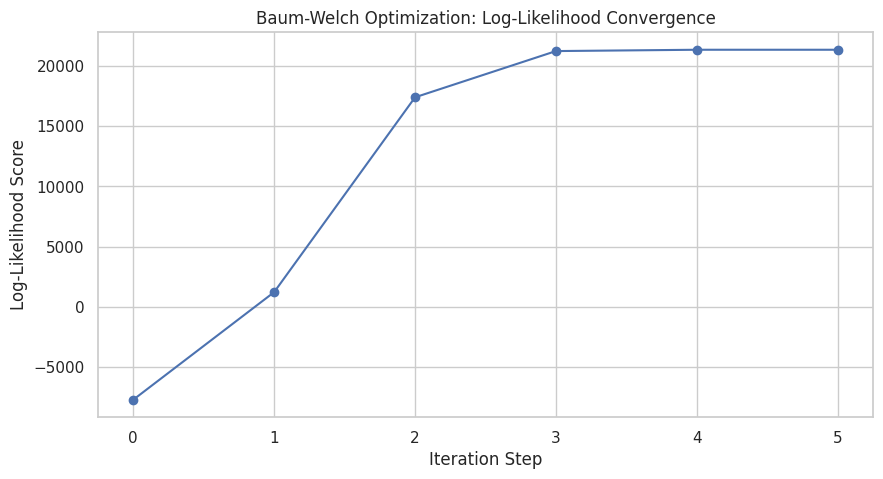

In [19]:
activity_hmm = hmm.GaussianHMM(
    n_components=n_hidden_states, 
    covariance_type="full", 
    n_iter=1000, 
    tol=strict_tolerance, 
    init_params="kmeans",
    random_state=42,
    min_covar=0.01,
    verbose=False   # suppresses the built-in warning print
)

activity_hmm.fit(X_train_scaled, train_lengths)

# Explicit convergence check
if activity_hmm.monitor_.converged:
    print("Model converged successfully.")
else:
    print(f"Model did not converge after {activity_hmm.n_iter} iterations. "
          f"Final log-likelihood: {activity_hmm.monitor_.history[-1]:.4f}")
    
# Visualize optimization convergence
plt.figure(figsize=(10, 5))
plt.plot(activity_hmm.monitor_.history, marker='o', linestyle='-', color='b')
plt.title("Baum-Welch Optimization: Log-Likelihood Convergence")
plt.xlabel("Iteration Step")
plt.ylabel("Log-Likelihood Score")
plt.grid(True)
plt.show()

## 4. Evaluation on Unseen Data

To rigorously evaluate the model's ability to generalize, the trained Hidden Markov Model is tested against a novel dataset not seen during the training phase. 

The `predict` method within the `hmmlearn` library implements the **Viterbi algorithm**. This dynamic programming algorithm decodes the most probable sequence of hidden states (activities) given the sequence of observed sensor features.

Crucially, the raw test features are normalized using the exact same `StandardScaler` fitted during the training phase. Fitting a new scaler on the test data would introduce data leakage and invalidate the evaluation.

Model performance is quantified using the confusion matrix to calculate the following metrics for each state:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
$$Sensitivity \ (Recall) = \frac{TP}{TP + FN}$$
$$Specificity = \frac{TN}{TN + FP}$$
$$F1 \ Score = 2 \times \frac{Precision \times Sensitivity}{Precision + Sensitivity}$$

In [14]:
# 1. Define the path and compile the unseen test data
unseen_data_dir = os.path.join(project_root, 'data', 'unseen_test_data')
raw_test_features, test_lengths, y_test_true = compile_training_matrix(unseen_data_dir, window_size=50)

# 2. Normalize using the PREVIOUSLY FITTED scaler
X_test_scaled = scaler.transform(raw_test_features)

# 3. Decode the most probable sequence using the Viterbi algorithm
y_pred_viterbi = activity_hmm.predict(X_test_scaled, test_lengths)

def generate_evaluation_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> pd.DataFrame:
    """
    Computes classification metrics for each distinct hidden state and returns a formatted table.
    """
    state_labels = ['Standing', 'Walking', 'Jumping', 'Still']
    cm = confusion_matrix(y_true, y_pred)
    metrics_list = []
    
    for i in range(len(state_labels)):
        tp = cm[i, i]
        fn = np.sum(cm[i, :]) - tp
        fp = np.sum(cm[:, i]) - tp
        tn = np.sum(cm) - (tp + fp + fn)
        
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        accuracy = (tp + tn) / np.sum(cm)
        
        metrics_list.append({
            "State (Activity)": state_labels[i],
            "Number of Samples": np.sum(cm[i, :]),
            "Sensitivity": round(sensitivity, 4),
            "Specificity": round(specificity, 4),
            "Overall Accuracy": round(accuracy, 4)
        })
        
    df_metrics = pd.DataFrame(metrics_list)
    
    # Calculate macro F1-score across all classes
    overall_f1 = f1_score(y_true, y_pred, average='macro')
    print(f"Model Macro F1-Score: {overall_f1:.4f}\n")
    
    return df_metrics

# Generate and display the final metrics table
evaluation_table = generate_evaluation_metrics(y_test_true, y_pred_viterbi)
display(evaluation_table)

Model Macro F1-Score: 0.2186



,State (Activity),Number of Samples,Sensitivity,Specificity,Overall Accuracy
0,Standing,138,0.0000,0.6887,0.5583
1,Walking,143,0.0000,0.5751,0.4623
2,Jumping,244,0.7869,0.9794,0.9150
3,Still,204,0.0098,0.8248,0.5967


## 4.1 Diagnostic Visualizations
The following diagnostic plots provide transparency into the internal parameter structuring of the trained model, mapping the theoretical transition and emission probabilities to the empirical data.

1. **Confusion Matrix**: Illustrates the true positives versus misclassifications for the Viterbi decoded sequence.
2. **Transition Matrix Heatmap**: Visualizes the learned probability of shifting from one physical state to another over time.
3. **Emission Probabilities Heatmap**: Displays the Gaussian means for the top extracted features across the hidden states.

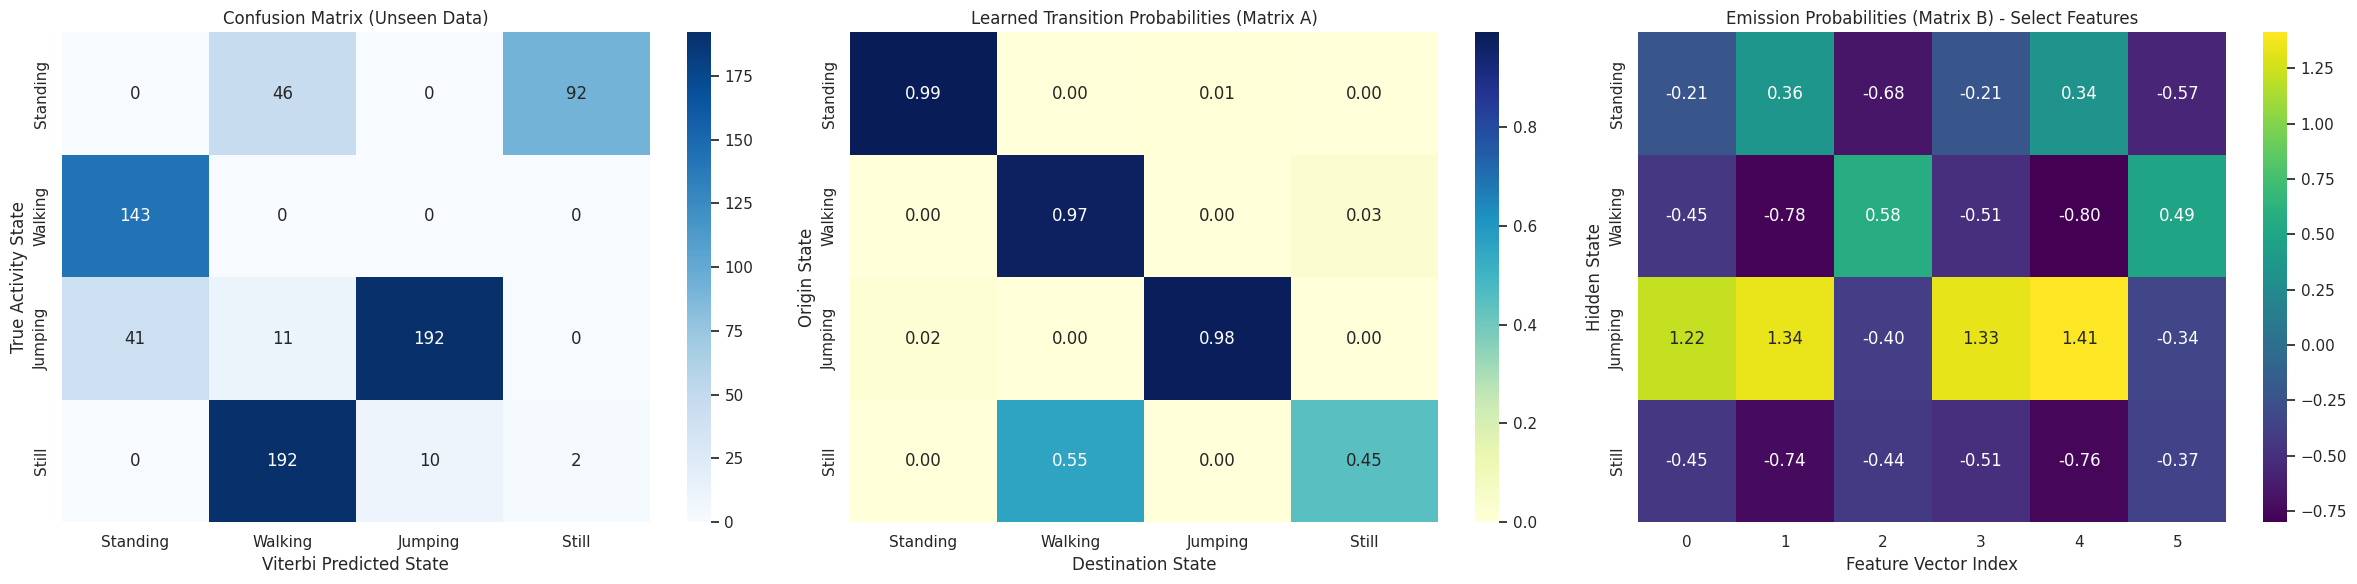

In [15]:
def plot_model_diagnostics(model, y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """
    Renders diagnostic heatmaps for model evaluation including the Confusion Matrix,
    Transition Probabilities, and Emission Probabilities.
    """
    state_names = ['Standing', 'Walking', 'Jumping', 'Still']
    fig, axes = plt.subplots(1, 3, figsize=(24, 6))
    
    # 1. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=state_names, yticklabels=state_names, ax=axes[0])
    axes[0].set_title('Confusion Matrix (Unseen Data)')
    axes[0].set_ylabel('True Activity State')
    axes[0].set_xlabel('Viterbi Predicted State')
    
    # 2. Transition Matrix (Matrix A)
    sns.heatmap(model.transmat_, annot=True, cmap='YlGnBu', fmt='.2f',
                xticklabels=state_names, yticklabels=state_names, ax=axes[1])
    axes[1].set_title('Learned Transition Probabilities (Matrix A)')
    axes[1].set_ylabel('Origin State')
    axes[1].set_xlabel('Destination State')
    
    # 3. Emission Means (Matrix B) 
    # Visualizing the first 6 features (e.g., Variance and RMS for X, Y, Z axes)
    sns.heatmap(model.means_[:, :6], annot=True, cmap='viridis', fmt='.2f',
                yticklabels=state_names, ax=axes[2])
    axes[2].set_title('Emission Probabilities (Matrix B) - Select Features')
    axes[2].set_ylabel('Hidden State')
    axes[2].set_xlabel('Feature Vector Index')
    
    plt.tight_layout()
    plt.show()

# Execute the visualization function
plot_model_diagnostics(activity_hmm, y_test_true, y_pred_viterbi)